In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

data collection and Processing

In [3]:
#loading the csv data to a pandas DataFrame
gold_data=pd.read_csv('gld_price_data.csv')

In [4]:
gold_data.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
#last 5 values
gold_data.tail()


,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [6]:
# finding rows and cloumns
gold_data.shape

(2290, 6)

In [7]:
gold_data.info()#we don't have missing values therefore no need to do preprocessing.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [9]:
#getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


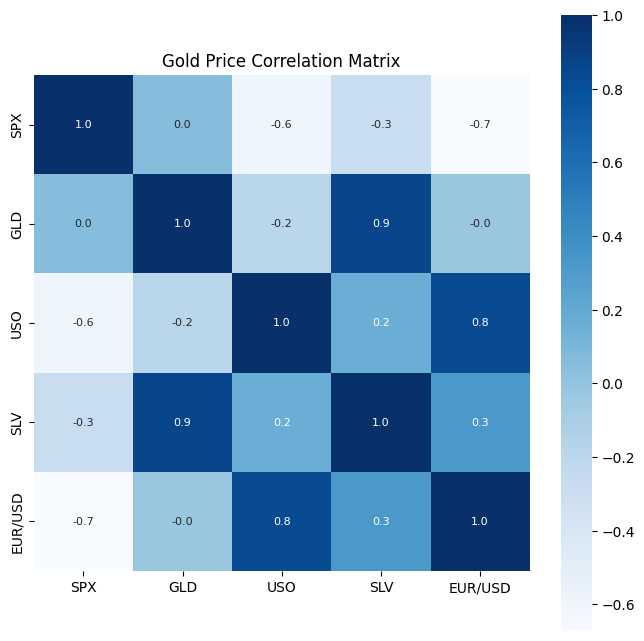

In [10]:
#correlation : positive and the negative
# Correlation matrix banao
correlation = gold_data.corr(numeric_only=True)

# Heatmap banao
plt.figure(figsize=(8, 8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', 
            annot=True, annot_kws={'size': 8}, cmap='Blues')
plt.title('Gold Price Correlation Matrix')
plt.show()


In [11]:
#gold correlation values
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


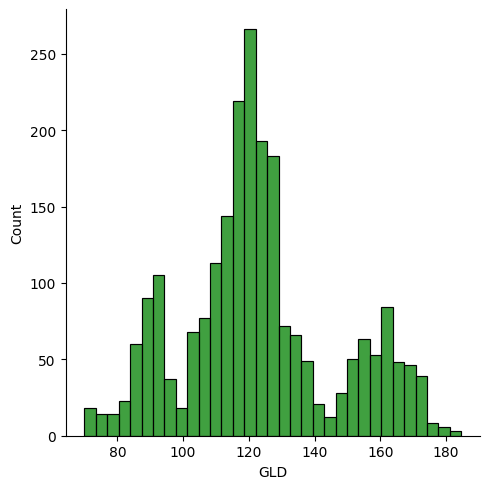

In [12]:
#checking the distibution of GLD price
sns.displot(gold_data['GLD'],color='green')

In [13]:
#Spiltting the features and Target
X=gold_data.drop(['Date','GLD'],axis=1)
Y=gold_data['GLD']

In [14]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [15]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [16]:
#seperating into testing and Test Data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
#model training: Random Forest Regressor
regressor=RandomForestRegressor(n_estimators=100)
#trianing the model
regressor.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
#model evaluation
#prediction on test data
test_data_prediction=regressor.predict(X_test)

In [41]:
print(test_data_prediction)

[168.66759924  81.83660002 116.2485     127.78270069 120.99620112
 154.65019723 150.06369883 126.0061001  117.52489852 125.88820105
 116.77670098 172.12490018 141.5921985  167.87629824 115.21040005
 117.56900031 138.87870363 170.45650051 159.34960336 160.83099998
 155.10540033 125.26920019 175.54699978 157.31180407 125.2542004
  93.87609985  77.32420014 120.56860003 119.10479947 167.43879958
  88.38550035 125.11230018  91.13460104 117.88570006 121.14349905
 136.03990102 115.34400117 114.72960062 147.45749982 107.34020114
 104.20650215  87.22789785 126.47600031 117.89590001 152.57309936
 119.68989998 108.31609984 108.1765982   93.17950031 127.11229785
  74.92500059 113.65879974 121.24710031 111.30119893 118.77049884
 120.66609917 158.00499997 168.74310165 147.30179671  85.76029833
  94.31800037  86.81709859  90.56510022 118.98220051 126.52360085
 127.46520015 170.75990057 122.27179945 117.32779862  98.83740029
 168.58090107 143.0657984  132.29370294 121.16320274 120.8960992
 119.7124004

In [19]:
# R squared error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print("R squared error: error_score:", error_score)

R squared error: error_score: 0.9887308145737973


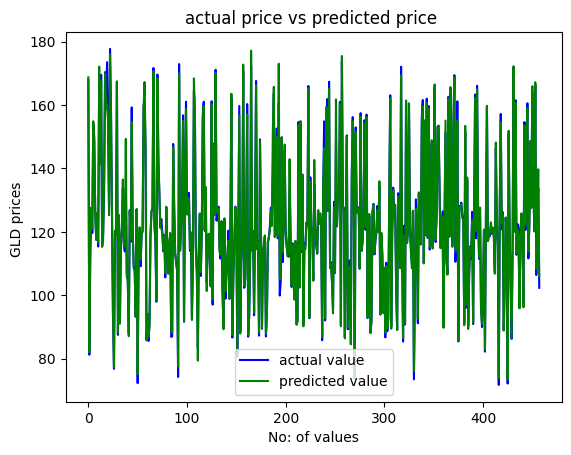

In [20]:
# comparing the actual and predicted values in a plot
Y_test=list(Y_test)
plt.plot(Y_test, color="blue",label="actual value")
plt.plot(test_data_prediction,color='green',label='predicted value')
plt.title("actual price vs predicted price ")
plt.xlabel("No: of values")
plt.ylabel("GLD prices ")
plt.legend()
plt.show()

In [ ]:
#recap of what we have done so far
#imported all the dependenceis needed
#data collection by loading the csv file by using pandas
#

In [21]:
import pickle

# Model save karo
with open('gold_price_model.pkl', 'wb') as file:
    pickle.dump(regressor, file)

print("✅ Model saved successfully!")

✅ Model saved successfully!
